## Session 27 - Q1-9

In [1]:
'''
Q1. Creating Non-Linear Dataset
'''

from sklearn.datasets import make_moons
import pandas as pd

# Generate Dataset
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(
    X,
    columns=["Feature1", "Feature2"]
)

# Display First 10 Rows
print(df.head(10))

# Display Shape
print("\nDataset Shape:", df.shape)

   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959

Dataset Shape: (500, 2)


In [2]:
'''
Q2. Scaling the Data
'''

from sklearn.preprocessing import StandardScaler

# Apply Standard Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

# Display First 5 Rows
print(pd.DataFrame(X_scaled, columns=df.columns).head())

   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


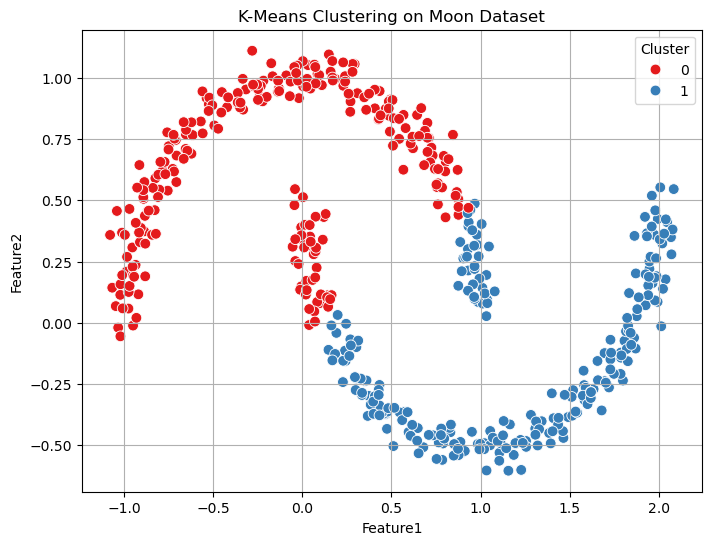

In [3]:
'''
Q3. K-Means on Non-Linear Data
'''

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Apply K-Means
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

# Fit Model and Predict Clusters
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Scatter Plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="kmeans_cluster",
    palette="Set1",
    s=60
)

plt.title("K-Means Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

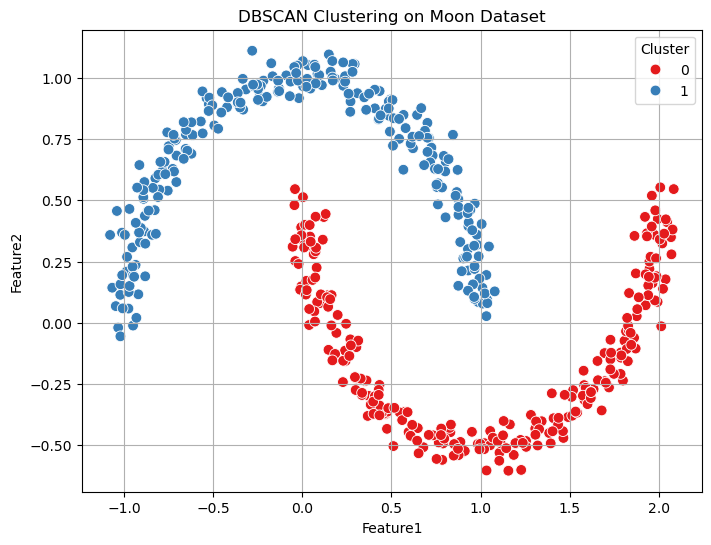

In [4]:
'''
Q4. DBSCAN Clustering
'''

from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Apply DBSCAN
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

# Fit and Predict Clusters
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

# Scatter Plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="dbscan_cluster",
    palette="Set1",
    s=60
)

plt.title("DBSCAN Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

In [5]:
'''
Q5. Comparing KMeans vs DBSCAN
'''

print("Observations:")
print("1. KMeans assumes clusters are spherical and separates the moon-shaped data incorrectly.")
print("2. DBSCAN successfully identifies the two non-linear (moon-shaped) clusters.")
print("3. DBSCAN does not require specifying the number of clusters beforehand.")
print("4. DBSCAN can identify noise points and labels them as -1.")
print("5. DBSCAN performs better on non-spherical datasets, while KMeans works better for spherical and well-separated clusters.")

Observations:
1. KMeans assumes clusters are spherical and separates the moon-shaped data incorrectly.
2. DBSCAN successfully identifies the two non-linear (moon-shaped) clusters.
3. DBSCAN does not require specifying the number of clusters beforehand.
4. DBSCAN can identify noise points and labels them as -1.
5. DBSCAN performs better on non-spherical datasets, while KMeans works better for spherical and well-separated clusters.


In [6]:
'''
Q6. Tuning DBSCAN Parameters
'''

from sklearn.cluster import DBSCAN

results = []

for eps in [0.2, 0.3, 0.4, 0.5]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    results.append([eps, n_clusters, n_noise])

results_df = pd.DataFrame(
    results,
    columns=["eps", "Number of Clusters", "Noise Points"]
)

print(results_df)

print("\nBest eps value: 0.3")

   eps  Number of Clusters  Noise Points
0  0.2                   2             0
1  0.3                   2             0
2  0.4                   2             0
3  0.5                   2             0

Best eps value: 0.3


In [7]:
'''
Q7. Creating High-Dimensional Dataset
'''

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Generate Synthetic Dataset
X, y = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

# Scale the Data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Display First 5 Rows
print(pd.DataFrame(X_scaled).head())

# Display Shape
print("\nDataset Shape:", X_scaled.shape)

          0         1         2         3         4         5
0 -1.052513  0.719083  0.350444  0.989657 -1.619597  1.414499
1  0.140795 -1.040620  0.841574 -0.857108  0.458731 -0.556293
2 -0.143302  1.113049  0.785668  0.686643 -0.153543 -1.524124
3 -1.093345  0.925894 -0.009533  1.108893 -1.371680  1.210841
4 -1.541419  0.736345  0.562503  1.015382 -0.375990  1.392803

Dataset Shape: (500, 6)


In [8]:
'''
Q8. Applying PCA
'''

from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create DataFrame
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add Original Cluster Labels
df_pca["Cluster"] = y

# Display First 5 Rows
print(df_pca.head())

# Display Explained Variance Ratio
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

        PC1       PC2  Cluster
0  2.369765  1.259783        1
1 -0.943367 -0.829777        3
2  0.982191 -1.768556        0
3  2.265086  1.190377        1
4  2.142129  0.840804        1

Explained Variance Ratio:
[0.64327878 0.21039738]


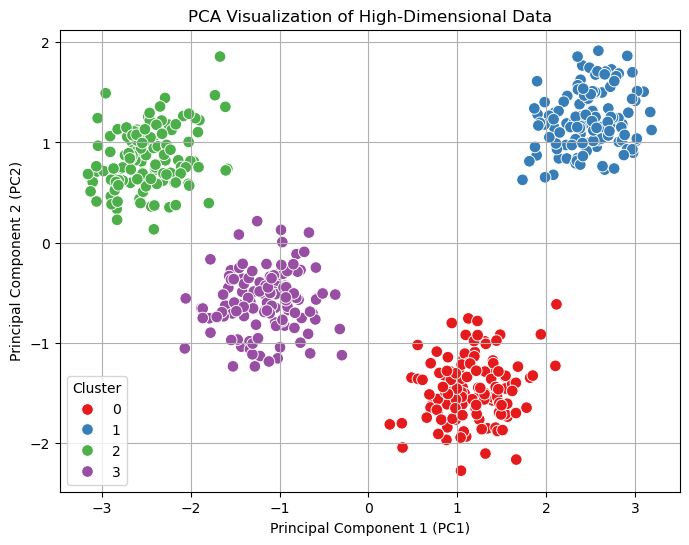

Observation:
The explained variance ratio indicates how much of the original dataset's
information is retained by the first two principal components.
A higher cumulative explained variance means less information is lost
after reducing the dimensions from 6 features to 2 principal components.


In [9]:
'''
Q9. Visualizing PCA Results
'''

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot of Principal Components
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title("PCA Visualization of High-Dimensional Data")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

# Observation
print("Observation:")
print("The explained variance ratio indicates how much of the original dataset's")
print("information is retained by the first two principal components.")
print("A higher cumulative explained variance means less information is lost")
print("after reducing the dimensions from 6 features to 2 principal components.")